In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df = pd.read_csv("economic_index.csv")

In [3]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [5]:
df.drop(columns=['Unnamed: 0','year','month'],inplace=True)

In [6]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [7]:
df.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


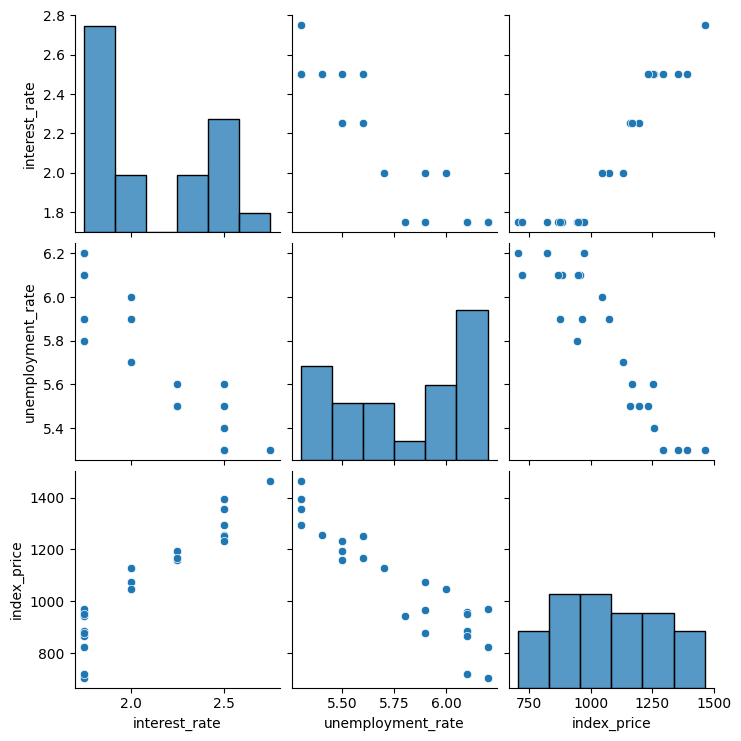

In [8]:
sns.pairplot(df)

In [9]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


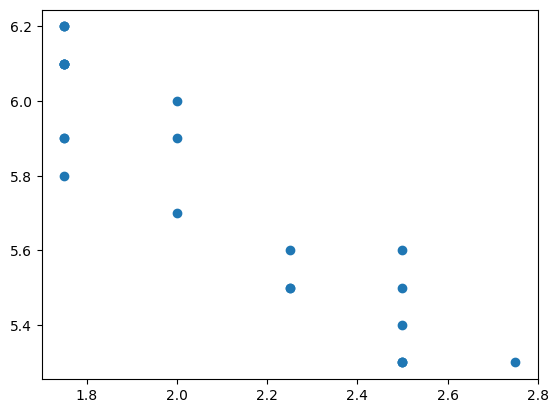

In [14]:
plt.scatter(df['interest_rate'],df['unemployment_rate'])

In [19]:
X=df.iloc[:,:-1]

In [21]:
y = df.iloc[:,-1]

In [22]:
y

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256
5,1254
6,1234
7,1195
8,1159
9,1167


In [20]:
X

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4
5,2.50,5.6
6,2.50,5.5
7,2.25,5.5
8,2.25,5.5
9,2.25,5.6


In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [27]:
X_train

,interest_rate,unemployment_rate
9,2.25,5.6
13,1.75,5.9
1,2.50,5.3
21,1.75,6.2
5,2.50,5.6
2,2.50,5.3
12,2.00,6.0
15,1.75,6.1
3,2.50,5.3
4,2.50,5.4


<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

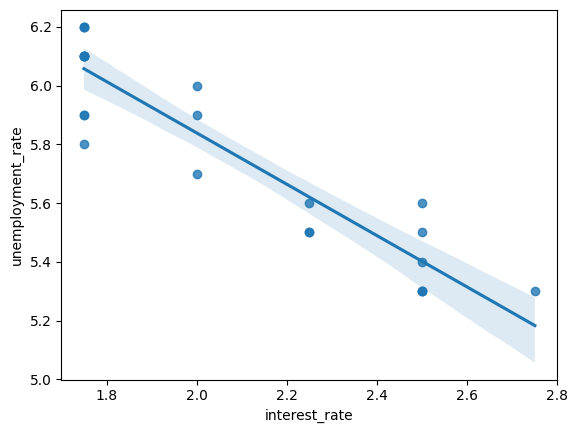

In [29]:
sns.regplot(x=df['interest_rate'], y=df['unemployment_rate'])

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()

In [33]:
scaler.fit_transform(X_train)
scaler.transform(X_test)
#or
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

array([[ 0.55339859, -0.84858687],
       [-0.9486833 ,  1.36439457],
       [ 2.05548048, -1.48086727],
       [-0.9486833 ,  1.04825436],
       [-0.19764235,  0.41597395]])

In [34]:
lr = LinearRegression(n_jobs=-1)

In [35]:
lr.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [36]:
from sklearn.model_selection import cross_val_score
cv = cross_val_score(lr,X_train,y_train,cv=10,scoring='neg_mean_squared_error')
print(cv)
print(np.mean(cv))

[  -897.13612817  -2036.88169183   -744.51895834 -14901.09141484
  -4790.36974793 -12011.66661252 -16307.82263206  -2475.48435742
   -537.88905313  -1855.17142631]
-5655.803202255214


In [37]:
#prediction
y_pred = lr.predict(X_test)

In [38]:
y_pred

array([1204.14403741,  821.62603274, 1406.38534684,  857.68137178,
        994.85736555])

In [39]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [40]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
rmse = np.sqrt(mse)
print('mse',mse)
print('mae',mae)
print('rmse',rmse)
print('r2',r2)

mse 6957.105303258842
mae 71.71878409976634
rmse 83.40926389351989
r2 0.8254940547158574


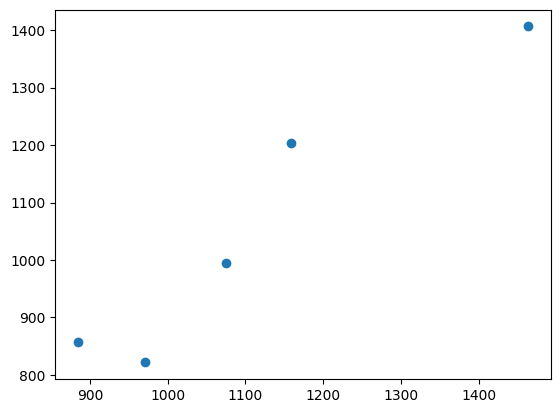

In [41]:
plt.scatter(y_test,y_pred)

In [42]:
residuals = y_test - y_pred
print(residuals)

8     -45.144037
16    149.373967
0      57.614653
18     26.318628
11     80.142634
Name: index_price, dtype: float64


<Axes: xlabel='index_price', ylabel='Density'>

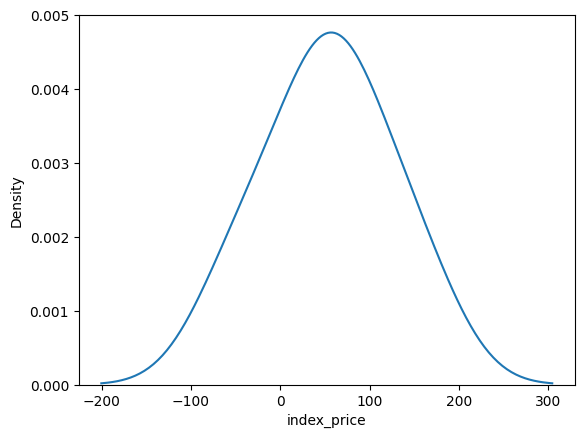

In [44]:
sns.kdeplot(residuals)

In [45]:
import statsmodels.api as sm

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())


                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.996
Model:                            OLS   Adj. R-squared (uncentered):              0.995
Method:                 Least Squares   F-statistic:                              2508.
Date:                Fri, 30 Jan 2026   Prob (F-statistic):                    1.10e-26
Time:                        16:59:07   Log-Likelihood:                         -136.70
No. Observations:                  24   AIC:                                      277.4
Df Residuals:                      22   BIC:                                      279.8
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------